In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from lightgbm import LGBMClassifier

In [2]:
train = pd.read_csv('data/clean/train_clean.csv')
test = pd.read_csv('data/clean/test_clean.csv')

In [3]:
X_train = train.drop("income", axis=1)
y_train = train["income"].str.strip().map({"<=50K": 0, ">50K": 1})

X_test = test.drop("income", axis=1)
y_test = test["income"].str.strip().map({"<=50K": 0, ">50K": 1})

usamodos dos tipos de endcoging

1. codificación binaria para gender, porque solo tiene dos categorías: female y male.vpor eso se transforma en 0 y 1

2. one hot Encoding para las variables categoricas nominales como workclass, marital status, occupation,relationship,race y native country. Se utiliza este método porque estas categorías no tienen un orden natural.

Despues, se alinean las columnas de train y test para asegurar que ambos conjuntos tengan exactamente la misma estructura.

In [4]:
X_train["gender"] = X_train["gender"].map({"Female": 0, "Male": 1})
X_test["gender"] = X_test["gender"].map({"Female": 0, "Male": 1})

In [5]:
cat_cols = ["workclass", "marital-status", "occupation", "relationship", "race", "native-country"]

X_train_encoded = pd.get_dummies(X_train, columns=cat_cols, drop_first=True, dtype=int)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols, drop_first=True, dtype=int)

# Alineamos dataframes
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

In [6]:
# Hecho pro IA
# Limpieza de nombres de columnas (Evita que LightGBM dé warnings por caracteres raros)
X_train_encoded.columns = [re.sub(r'[^\w\s]', '_', col) for col in X_train_encoded.columns]
X_test_encoded.columns = [re.sub(r'[^\w\s]', '_', col) for col in X_test_encoded.columns]

In [7]:
print("Columnas en Train y Test después de get_dummies:", X_train_encoded.shape[1])

Columnas en Train y Test después de get_dummies: 43


In [8]:
def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    
    # Matriz de confusion
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
    plt.title(f"Matriz de Confusión - {nombre}")
    plt.ylabel('Realidad')
    plt.xlabel('Predicción')
    plt.show()

    # Metricas
    resultados = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_proba)
    }
    
    return resultados

### Random Forest

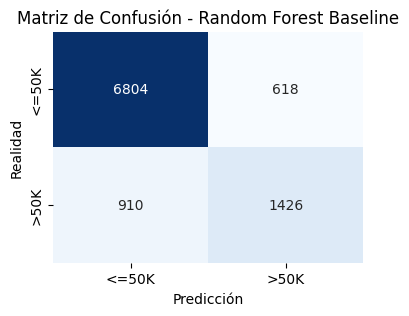

{'Modelo': 'Random Forest Baseline',
 'Accuracy': 0.8434105349456856,
 'Precision': 0.6976516634050881,
 'Recall': 0.610445205479452,
 'F1': 0.6511415525114155,
 'ROC_AUC': 0.8925862358943976}

In [9]:
# Baseline con Random Forest
rf_baseline = RandomForestClassifier(random_state=42)

rf_baseline.fit(X_train_encoded, y_train)

resultado_rf_baseline = evaluar_modelo("Random Forest Baseline", rf_baseline, X_test_encoded, y_test)

resultado_rf_baseline

In [10]:
# Validacion cruzada
cv_rf_baseline = cross_val_score(
    rf_baseline,
    X_train_encoded,
    y_train,
    cv=5,
    scoring="f1", 
    n_jobs=-1
)

print("F1 medio CV:", cv_rf_baseline.mean())
print("Desviación:", cv_rf_baseline.std())

F1 medio CV: 0.6643314844390259
Desviación: 0.0031944330301258896


In [11]:
# Hyperparameter tuning con RandomizedSearchCV
param_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_rf,
    n_iter=10,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train_encoded, y_train)

print("Mejores parámetros:")
print(rf_search.best_params_)

Mejores parámetros:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}


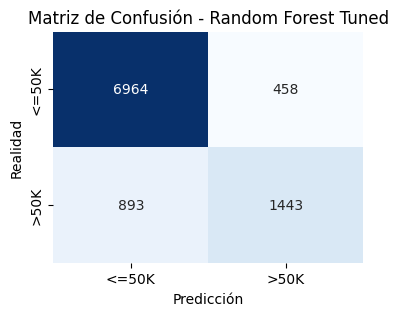

{'Modelo': 'Random Forest Tuned',
 'Accuracy': 0.8615494978479197,
 'Precision': 0.7590741714886902,
 'Recall': 0.617722602739726,
 'F1': 0.681142317677602,
 'ROC_AUC': 0.9158646325898937}

In [12]:
# Evaluamos el modelo con los mejores parámetros
resultado_rf_tuned = evaluar_modelo(
    "Random Forest Tuned",
    rf_search.best_estimator_,
    X_test_encoded,
    y_test
)

resultado_rf_tuned

### LightGBM

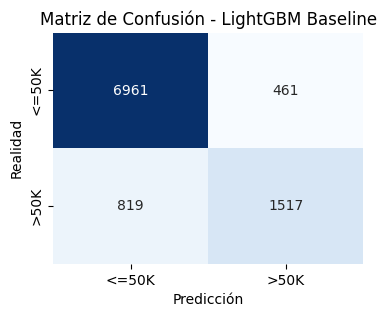

{'Modelo': 'LightGBM Baseline',
 'Accuracy': 0.8688255790120927,
 'Precision': 0.7669362992922144,
 'Recall': 0.6494006849315068,
 'F1': 0.703291608715809,
 'ROC_AUC': 0.9252041724805558}

In [13]:
# Baseline con LightGBM
lgbm_baseline = LGBMClassifier(random_state=42, verbose=-1)

lgbm_baseline.fit(X_train_encoded, y_train)

resultado_lgbm_baseline = evaluar_modelo(
    "LightGBM Baseline",
    lgbm_baseline,
    X_test_encoded,
    y_test
)

resultado_lgbm_baseline

In [14]:
# Validacion cruzada para LightGBM
cv_lgbm_baseline = cross_val_score(
    lgbm_baseline,
    X_train_encoded,
    y_train,
    cv=5,
    scoring="f1", 
    n_jobs=-1
)

print("F1 medio CV:", cv_lgbm_baseline.mean())
print("Desviación:", cv_lgbm_baseline.std())

F1 medio CV: 0.7119610536295536
Desviación: 0.0026025889717588685


In [15]:
# Hyperparameter tuning con RandomizedSearchCV para LightGBM
param_lgbm = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 5, 10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

lgbm_search = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=param_lgbm,
    n_iter=10,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=42
)

lgbm_search.fit(X_train_encoded, y_train)

print("Mejores parámetros:")
print(lgbm_search.best_params_)

Mejores parámetros:
{'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


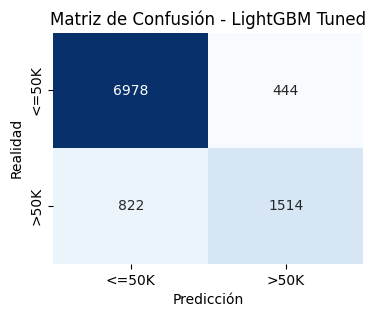

{'Modelo': 'LightGBM Tuned',
 'Accuracy': 0.8702602992416478,
 'Precision': 0.7732379979570991,
 'Recall': 0.6481164383561644,
 'F1': 0.7051700046576619,
 'ROC_AUC': 0.925813419609602}

In [16]:
# Evaluamos el modelo con los mejores parámetros
resultado_lgbm_tuned = evaluar_modelo(
    "LightGBM Tuned",
    lgbm_search.best_estimator_,
    X_test_encoded,
    y_test
)

resultado_lgbm_tuned

In [17]:
resultados = pd.DataFrame([
    resultado_rf_baseline,
    resultado_rf_tuned,
    resultado_lgbm_baseline,
    resultado_lgbm_tuned
])

resultados.sort_values(by="F1", ascending=False)

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
3,LightGBM Tuned,0.870260,0.773238,0.648116,0.705170,0.925813
2,LightGBM Baseline,0.868826,0.766936,0.649401,0.703292,0.925204
1,Random Forest Tuned,0.861549,0.759074,0.617723,0.681142,0.915865
0,Random Forest Baseline,0.843411,0.697652,0.610445,0.651142,0.892586


## Conclusion

despues entrenar y comparar los cuatro modelos, el mejor rendimiento general lo obtiene lightgbm tuned.este modelo consigue una accuracy de 0,8703, un f1-score de 0,7052 y un roc-auc de 0,9258.

Aunque la mejora respecto a lightgbm baseline no es muy grande, lightgbm tuned obtiene el mejor resultado global. En random forest si se observa una mejora mas clara al aplicar fine tuning, pasando de un f1-score de 0,6511 a 0,6811 , aun asi, random forest queda por debajo de lightgbm.

Como la variable objetivo esta desbalanceada, no se ha elegido el modelo unicamente por la accuracy. Tambien se han tenido en cuenta precision, recall, f1-score y roc-auc ,en este caso, el f1-score es especialmente importante porque combina precision y recall.

Los resultados muestran que lightgbm se adapta mejor a este problema que random Forest. Ademas, los resultados de validacion cruzada son coherentes con los resultados obtenidos en test, por lo que no se observan señales claras de sobreajuste.Por tanto, el modelo seleccionado como mejor opción final es lightgbm tuned.